# MLB Salary Prediction
### Sikem Nkwawir

## Introduction


This project aims to predict the salaries of Major League Baseball players based on their performance metrics. This will be done using the dataset provided which includes features like OBP, batting average, and hits amongst others. I will start by using a basic least square regression model. Using stepwise feature selection, and different penalization techniques, the outcome will be a model which has been optimized using only the most important features to accurately predict player salaries with precision.

In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,median_absolute_error
from sklearn.metrics import mean_squared_log_error,r2_score,max_error
import math
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.stattools import durbin_watson

## 1. EDA Analysis

To begin, I will first import my dataset. This dataset, obtained from Amstat, provides us with the 1992 stats of 337 MLB players along with their salaries. Once I have access to the dataset, I will conduct my EDA analysis.

In [271]:
columns = ['salary', 'batting_avg', 'OBP', 'runs', 'hits', 'doubles', 'triples', 'homeruns', 'RBI', 'walks', 'strike.outs','stolen.bases', 'errors', 'free.agency.elig', 'free.agent.91','arb.elig', 'arb.91', 'name']
data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/baseball.dat1.txt', sep='\\s+', names=columns)

data.head()

,salary,batting_avg,OBP,runs,hits,doubles,triples,homeruns,RBI,walks,strike.outs,stolen.bases,errors,free.agency.elig,free.agent.91,arb.elig,arb.91,name
0,3300,0.272,0.302,69,153,21,4,31,104,22,80,4,3,1,0,0,0,Andre Dawson
1,2600,0.269,0.335,58,111,17,2,18,66,39,69,0,3,1,1,0,0,Steve Buchele
2,2500,0.249,0.337,54,115,15,1,17,73,63,116,6,5,1,0,0,0,Kal Daniels
3,2475,0.260,0.292,59,128,22,7,12,50,23,64,21,21,0,0,1,0,Shawon Dunston
4,2313,0.273,0.346,87,169,28,5,8,58,70,53,3,8,0,0,1,0,Mark Grace


In [272]:
data.shape

(337, 18)

The following two cells are used in tandem to check the types of variables that I have. The info function allows us to gather information about the type of values stored in each feature. From that I know that I have 2 continuous features (batting average and OBP),  1 string feature (name) and the other 15 feautres hold integers. The nunique function is then used to see which of those integer holding features are actually integers and how many of them are categorial. Using that function I discover that 4 of those features are categorical (free.agency.elig, free.agent.91, arb.elig, arb.91), whereas the other 11 are actual integers. Each of those integer features represent a counting stat like the numble of runs a player had throughout the season.

In [273]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   salary            337 non-null    int64  
 1   batting_avg       337 non-null    float64
 2   OBP               337 non-null    float64
 3   runs              337 non-null    int64  
 4   hits              337 non-null    int64  
 5   doubles           337 non-null    int64  
 6   triples           337 non-null    int64  
 7   homeruns          337 non-null    int64  
 8   RBI               337 non-null    int64  
 9   walks             337 non-null    int64  
 10  strike.outs       337 non-null    int64  
 11  stolen.bases      337 non-null    int64  
 12  errors            337 non-null    int64  
 13  free.agency.elig  337 non-null    int64  
 14  free.agent.91     337 non-null    int64  
 15  arb.elig          337 non-null    int64  
 16  arb.91            337 non-null    int64  
 1

In [274]:
data.nunique()

,0
salary,208
batting_avg,133
OBP,139
runs,105
hits,163
doubles,44
triples,14
homeruns,36
RBI,106
walks,90


Now I will look at my target variable, salary. As the name suggests, this variable outlines how much each player made in the 1992 MLB season (in thousands of dollars). First I will look at the distribution of my variable. Understandably, I can see that the salary is skew right. To accurately predict what a player's salary might be, I want to make sure that the distribution my target variable is relatively uniform. I accomplish this by instead taking the log of the salary. Looking at the distribution of my new salary variable, I see that my transformation helped even out the data. There are still a few peaks and valleys, so that could affect the performance of my model later on. This issue might be fixed by using a different transformation, but for the purposes of this project, I will stick with log(salary). I created a new data frame to support this transformed variable, so going forward any mention of salary will refer to my transformed variable and not the original.

(array([164.,  53.,  21.,  44.,  21.,  18.,   9.,   3.,   3.,   1.]),
 array([ 109. ,  708.1, 1307.2, 1906.3, 2505.4, 3104.5, 3703.6, 4302.7,
        4901.8, 5500.9, 6100. ]),
 <BarContainer object of 10 artists>)

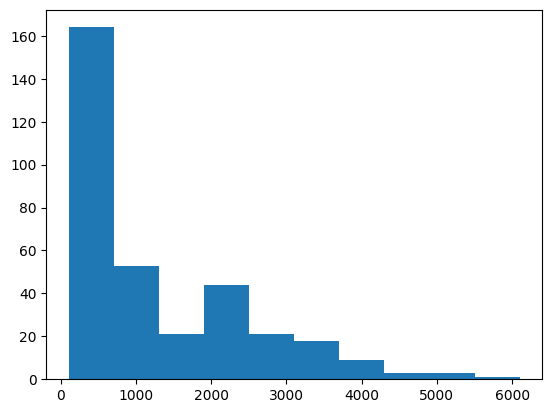

In [275]:
plt.hist(data['salary'])

(array([61., 27., 32., 23., 34., 36., 23., 54., 36., 11.]),
 array([4.69134788, 5.0938175 , 5.49628712, 5.89875673, 6.30122635,
        6.70369597, 7.10616558, 7.5086352 , 7.91110482, 8.31357443,
        8.71604405]),
 <BarContainer object of 10 artists>)

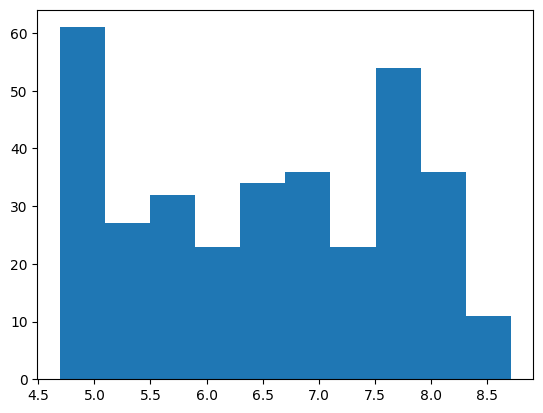

In [276]:
datat = data.copy()
datat['salary']=np.log(datat['salary'])
plt.hist(datat['salary'])

In [333]:
datat.head()

,salary,batting_avg,OBP,runs,hits,doubles,triples,homeruns,RBI,walks,strike.outs,stolen.bases,errors,free.agency.elig,free.agent.91,arb.elig,arb.91,name
0,8.101678,0.272,0.302,69,153,21,4,31,104,22,80,4,3,1,0,0,0,Andre Dawson
1,7.863267,0.269,0.335,58,111,17,2,18,66,39,69,0,3,1,1,0,0,Steve Buchele
2,7.824046,0.249,0.337,54,115,15,1,17,73,63,116,6,5,1,0,0,0,Kal Daniels
3,7.813996,0.260,0.292,59,128,22,7,12,50,23,64,21,21,0,0,1,0,Shawon Dunston
4,7.746301,0.273,0.346,87,169,28,5,8,58,70,53,3,8,0,0,1,0,Mark Grace


## 2. Least Square Regression

Now that I have gathered more information about my dataset and transformed my target variable, I can begin creating my first model. The first thing I do is setting my y to salary and my x to all of the other features except name. After that, I split my 2 variables into training and test sets and scale my x sets. The scaling is done because I have two feautures that represent percentages and other features that have values above 100, causing a magnitude difference of 1000. After scaling, I fit my linear regression model and recieved my evaluation metrics.

In [277]:
y = datat['salary']
x = datat.drop(['salary', 'name'], axis=1)

from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=123)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [278]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

LinearRegression()

In [279]:
print("TRAINING DATA RESULTS")

r_sq = model.score(x_train_scaled, y_train)
print("\ncoefficient of determination:",r_sq)
print("intercept:", model.intercept_)
print("feature coefficients:", model.coef_)

print("\nTESTING DATA RESULTS")
predict=model.predict(x_test_scaled)

print("\nR score:", r2_score(y_test,predict))
print("mean squared error:", mean_squared_error(y_test,predict))
print("MSE:", mean_squared_error(y_test,predict))
print("mean absolute error:", mean_absolute_error(y_test,predict))


TRAINING DATA RESULTS

coefficient of determination: 0.850301816981162
intercept: 6.4629058832101425
feature coefficients: [ 0.05839099 -0.09936878 -0.15888297  0.5797478  -0.08136454 -0.08780378
  0.11979409  0.18895087  0.09012739 -0.09949225  0.05510511 -0.05541863
  0.74783926 -0.10533654  0.46955218 -0.02098821]

TESTING DATA RESULTS

R score: 0.5960451066468704
mean squared error: 0.5138509494107417
MSE: 0.5138509494107417
mean absolute error: 0.535438960766149


Based on these values, I can see that my model is very well fit to my training data, and does not perform as well on my testing data. This means that I have an overfitting issue. Even with this error, however, I can see that my errors are small compared to my values. While I would ideally have a much better model, this is a good starting place.

It is possible that my fit in this case could have been better if I used less of my total data in my testing set or if I chose a different set of testing data.

## 3. Stepwise Selection

As I noticed previously, my base model ran into an overfitting issue. One way I can fix this is by used stepwise selection to choose only the most important variables. I will do this using SKLearn's SequentialFeatureSelector. I decided to select 8 features as that is half of my total predictors.

In [280]:
model = LinearRegression()
sfsb = SequentialFeatureSelector(model, direction='backward', n_features_to_select=8, cv=5)
sfsb.fit(x_train_scaled, y_train)

SequentialFeatureSelector(direction='backward', estimator=LinearRegression(),
                          n_features_to_select=8)

In [281]:
selected_features_b = x.columns[sfsb.get_support()]
selected_features_b

Index(['hits', 'triples', 'RBI', 'stolen.bases', 'errors', 'free.agency.elig',
       'free.agent.91', 'arb.elig'],
      dtype='object')

In [ ]:
y2 = datat['salary']
x2 = datat[selected_features_b]

from sklearn.model_selection import train_test_split

#for initial testing purpose I are spliting train test from train data

x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.33, random_state=123)

scaler = StandardScaler()
x_train2_scaled = scaler.fit_transform(x_train2)
x_test2_scaled = scaler.fit_transform(x_test2)
modelsel = LinearRegression()

In [283]:
modelsel.fit(x_train2_scaled, y_train2)

LinearRegression()

In [284]:
print("TRAINING DATA RESULTS")

r_sq2 = modelsel.score(x_train2_scaled, y_train2)
print(f"coefficient of determination: {r_sq2}")
print(f"intercept: {modelsel.intercept_}")
print(f"feature coefficients: {modelsel.coef_}")

print("\nTESTING DATA RESULTS")

predict2=modelsel.predict(x_test2_scaled)
print("\nR score:", r2_score(y_test2,predict2))
print("mean squared error:", mean_squared_error(y_test2,predict2))
print("MSE:", mean_squared_error(y_test2,predict2))
print("mean absolute error:", mean_absolute_error(y_test2,predict2))

TRAINING DATA RESULTS
coefficient of determination: 0.8448245666378563
intercept: 6.4629058832101425
feature coefficients: [ 0.40458978 -0.10950612  0.23471449  0.02462245 -0.05761765  0.75798344
 -0.1099184   0.4644585 ]

TESTING DATA RESULTS

R score: 0.5988238913160369
mean squared error: 0.5103161954964948
MSE: 0.5103161954964948
mean absolute error: 0.5328733344837502


From my backwards selection, I can see that the most valuable features are hits, triples, RBI, stolen.bases, errors, free.agency.elig, free.agent.91 and arb.elig. As someone who is a sports fan, these predictors being the most important makes sense because these are often the factors that you hear when people discuss a players performance. After determinitng these features, I re-established my x and y, using only my chosen predictors. After training my model again,  I found that my two R scores got closer together, suggesting that my fit issue is getting better. The overall change in the errors was very small, with all differences coming in the thousandths position. The changes may have been more substantial by selecting a different number of features or setting the number of feature to auto and changing the tolerance.

To make sure that the backwars selection chose the best 8 features, I also ran a forward selection with the same arguments and received the exact same features.

In [285]:
model = LinearRegression()
sfsf = SequentialFeatureSelector(model, direction='forward', n_features_to_select=8, cv=5)
sfsf.fit(x_train_scaled, y_train)

SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=8)

In [286]:
selected_features_f = x.columns[sfsf.get_support()]
selected_features_f

Index(['hits', 'triples', 'RBI', 'stolen.bases', 'errors', 'free.agency.elig',
       'free.agent.91', 'arb.elig'],
      dtype='object')

### Assumption Check

Following my selection, I needed to check my assumptions. While this ideally should have been done after the initial model, I think the reason I were asked to do it at this point was to eliminate the possibility that my model might not be getting much better due to not meeting all of the assumptions. The four assumptions I checked are normality of residuals, homoscedascity, linearity, auto-correlation and independence.

#### Normality of Residuals

To check normality I started by using a histogram, which revealed that aside from some outliers my residuals seemed to be mostly normal. Since it was not a perfect normal distribution, I decided to also use a Q-Q plot to ensure normality. This plot confirmed that my residuals are normally distributed.

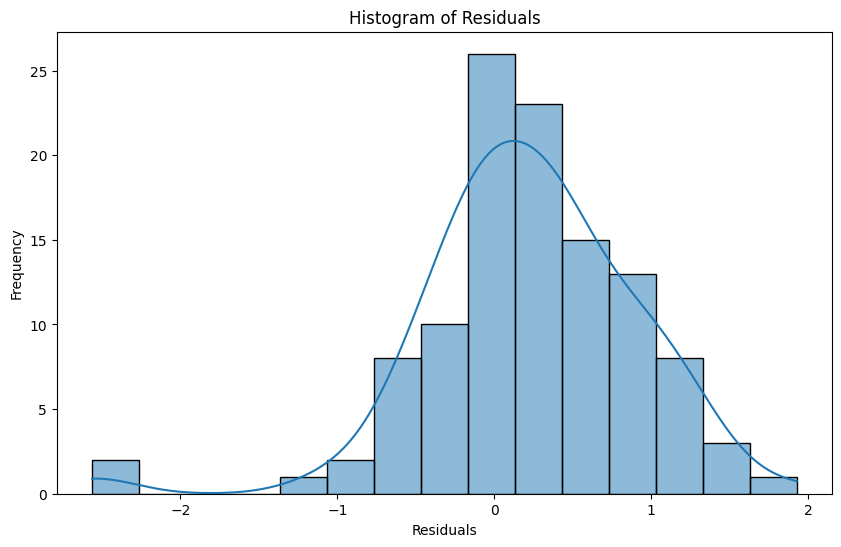

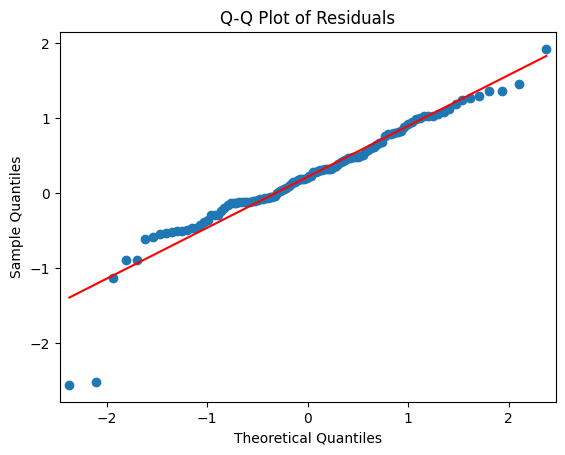

In [287]:
residuals = y_test2 - predict2

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

The following code will tell us who the outliers in my data are, their row numbers, and their stats in the selected features. Since both had negative residuals, it can be said that these two players made less than what they should have based on my model. Based on Freddie Benavides' stats, it makes sense that he would be paid less, but the same cannot be said for Calderon. Doing a simple search revelaed that during the 1990 MLB season, Calderon was entrenched in a contract dispute with the Montreal Expos and ended up getting a smaller contract than he would have preferred. (source: https://sabr.org/bioproj/person/ivan-calderon/)

In [332]:
threshold = 3 * np.std(residuals)
outliers = np.where(np.abs(residuals) > threshold)[0]

outlier_points = datat.iloc[outliers]
print(outlier_points[selected_features_b])

print("\n",outlier_points['name'])


     hits  triples  RBI  stolen.bases  errors  free.agency.elig  \
14    141        3   75            31       7                 1   
101    18        0    3             1       2                 0   

     free.agent.91  arb.elig  
14               0         0  
101              0         0  

 14     Ivan Calderon    
101    Freddie Benavides
Name: name, dtype: object


#### Homoscedascity and Linearity

To check homoscedascity and linearity, I plotted my predicted values against my residuals. Since there is no pattern in the placements of my points, I know that I have both homoscedascity and linearity.

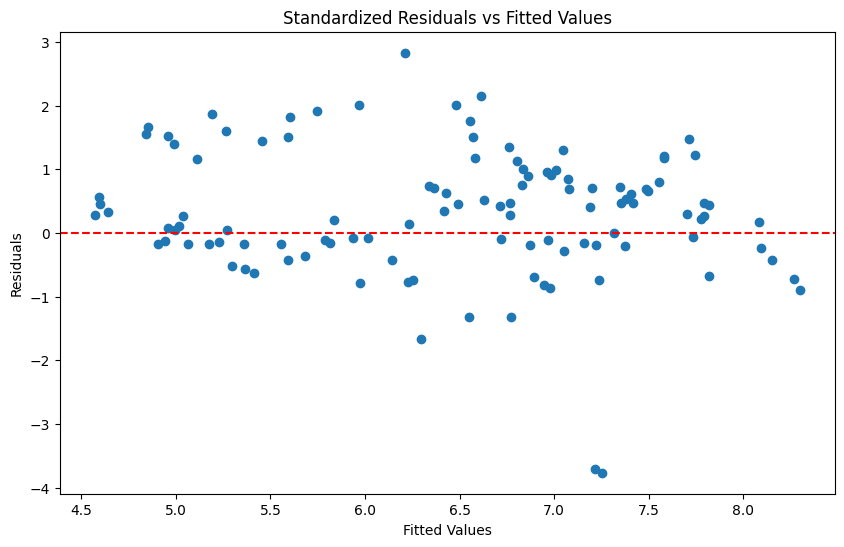

In [288]:
fitted_values = predict2
standardized_residuals = residuals / np.std(residuals)

plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, standardized_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Standardized Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

#### Auto-Correlation and Independence

To check both auto-correlation and independence, I use the same methods. First I used a Durbin Watson Test. This is a simple test where a value of 2 suggests auto-correlation and indepence. My value of 2.08 satisfies this condition, but to ensure there is no auto-corellation and independence, I also used an auto-correlation plot of the residuals which also showed that there is very little auto-correlation.

Durbin-Watson Test: 2.0681574825477367




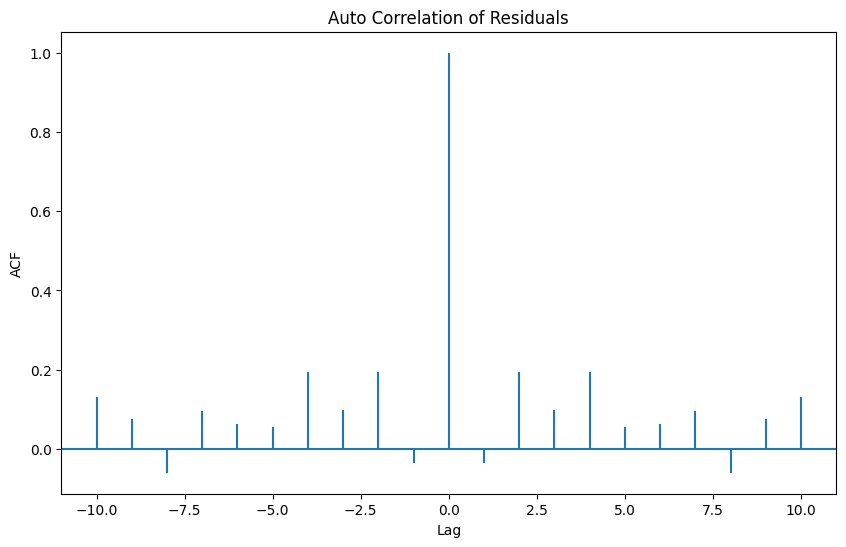

In [289]:
dw_test = durbin_watson(residuals)
print("Durbin-Watson Test:", dw_test)

print("\n")


plt.figure(figsize=(10, 6))
plt.acorr(residuals, maxlags=10)
plt.title('Auto Correlation of Residuals')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.show()

## 4. Shrinkage/Regularization Methods

Another method of improving the performance of my model is to use regularization. In this section I will use Elastic Net, Ridge and Lasso regularization to see which offers the best improvements. I will complete each other these using their respective cross validation and regularization functions from SKLearn.

### Elastic Net

The first method I will use is Elastic Net regularization. First I set my use cross validation to find the best alpha when l1_ratio is set to 0.5. After graphing the relationship between weights and alpha, I fit the model and got my evaluation metrics.

In [290]:
modelen = ElasticNetCV(l1_ratio=0.5, eps=0.00001,  alphas=np.logspace(-2, 4, 100), fit_intercept=True, precompute='auto', max_iter=1000, tol=0.0001, cv=None, copy_X=True)
modelen.fit(x_train_scaled, y_train)

al=modelen.alpha_
print("Ideal alpha:", al)

Ideal alpha: 0.02009233002565047


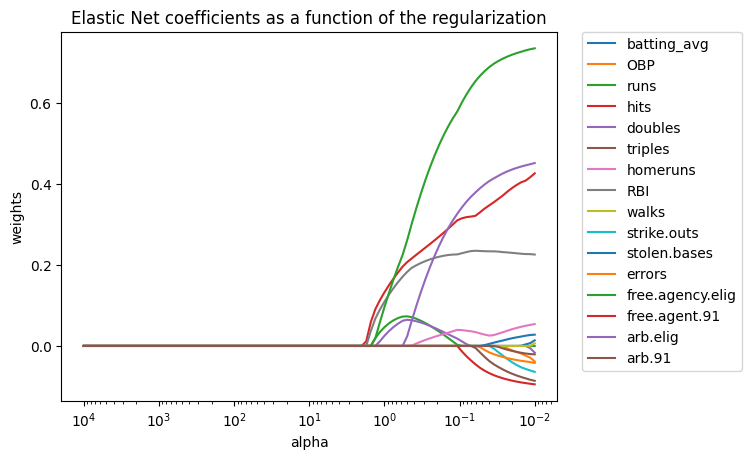

In [291]:
n_alphas = 100
alphas = np.logspace(-2, 4, n_alphas)
coefs = []
for a in alphas:
    ELN = ElasticNet(l1_ratio=0.5,alpha=a, fit_intercept=False)
    ELN.fit(x_train_scaled, y_train)
    coefs.append(ELN.coef_)

ax = plt.gca()

ax.plot(alphas, coefs,label=x.columns)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Elastic Net coefficients as a function of the regularization")
plt.axis("tight")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.show()

From this graph, I can see that as the alpha gets smaller, more of my features will be used in my final model.

In [292]:
model2 = ElasticNet(alpha=al, l1_ratio=.5,  max_iter=1000, copy_X=True, tol=0.001)
model2.fit(x_train_scaled, y_train)

ElasticNet(alpha=0.02009233002565047, tol=0.001)

In [293]:
print("TRAINING DATA RESULTS")

r_sq3 = model2.score(x_train_scaled, y_train)
print("\ncoefficient of determination:",r_sq3)
print("intercept:", model2.intercept_)
print("feature coefficients:", model2.coef_)

print("\nTESTING DATA RESULTS")
predict3=model2.predict(x_test_scaled)

print("R score:", r2_score(y_test,predict3))
print("mean squared error:", mean_squared_error(y_test,predict3))
print("MSE:", mean_squared_error(y_test,predict3))
print("mean absolute error:", mean_absolute_error(y_test,predict3))

TRAINING DATA RESULTS

coefficient of determination: 0.8451084881742641
intercept: 6.4629058832101425
feature coefficients: [ 0.         -0.01099685  0.          0.39245074 -0.         -0.0682068
  0.04546502  0.22549979  0.         -0.04153239  0.01888736 -0.03257701
  0.71864691 -0.08520721  0.43553318 -0.01227071]

TESTING DATA RESULTS
R score: 0.602849422524315
mean squared error: 0.5051955172542139
MSE: 0.5051955172542139
mean absolute error: 0.5351103527269642


From my Elastic Net regularization, I can see that there were 4 coefficients that had their weights reduced to zero (batting_avg, runs, doubles, walks). This yielded a better result than both my basic regression and my stepwise selection. All three errors reduced more than they did when I employed stepwise selection and the two R scores were closer together.

### Ridge Regularization

The second method I will use is Ridge regularization. Similarily, I first use cross validation to find the best alpha, then graph the weights vs the alphas and finally fit and evaluate my model.

In [294]:
modelrr = RidgeCV(alphas=np.logspace(-2, 4, 100), fit_intercept=True, cv=None)
modelrr.fit(x_train_scaled, y_train)

RidgeCV(alphas=array([1.00000000e-02, 1.14975700e-02, 1.32194115e-02, 1.51991108e-02,
       1.74752840e-02, 2.00923300e-02, 2.31012970e-02, 2.65608778e-02,
       3.05385551e-02, 3.51119173e-02, 4.03701726e-02, 4.64158883e-02,
       5.33669923e-02, 6.13590727e-02, 7.05480231e-02, 8.11130831e-02,
       9.32603347e-02, 1.07226722e-01, 1.23284674e-01, 1.41747416e-01,
       1.62975083e-01, 1.87381742e-0...
       4.03701726e+02, 4.64158883e+02, 5.33669923e+02, 6.13590727e+02,
       7.05480231e+02, 8.11130831e+02, 9.32603347e+02, 1.07226722e+03,
       1.23284674e+03, 1.41747416e+03, 1.62975083e+03, 1.87381742e+03,
       2.15443469e+03, 2.47707636e+03, 2.84803587e+03, 3.27454916e+03,
       3.76493581e+03, 4.32876128e+03, 4.97702356e+03, 5.72236766e+03,
       6.57933225e+03, 7.56463328e+03, 8.69749003e+03, 1.00000000e+04]))

In [295]:
al=modelrr.alpha_
print("Ideal alpha:",al)

Ideal alpha: 4.641588833612782


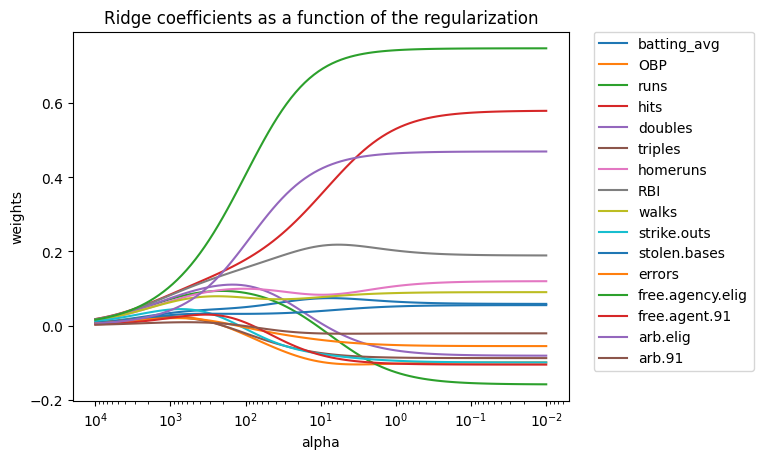

In [296]:
alphas = np.logspace(-2, 4, 100)
coefs = []
for a in alphas:
    RR = Ridge(alpha=a, fit_intercept=True)
    RR.fit(x_train_scaled, y_train)
    coefs.append(RR.coef_)

ax = plt.gca()

ax.plot(alphas, coefs,label=x.columns)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge coefficients as a function of the regularization")
plt.axis("tight")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.show()

From this graph, I can see that as the alpha gets smaller, more of my features will be used in my final model. As expected of Ridge selection, there doesn't seem to be any point where any of my weights will go to and stay at zero.

In [297]:
model3 = Ridge(alpha=al,  max_iter=1000, copy_X=True, tol=0.001)
model3.fit(x_train_scaled, y_train)

Ridge(alpha=4.641588833612782, max_iter=1000, tol=0.001)

In [298]:
print("TRAINING DATA RESULTS")

r_sq4 = model3.score(x_train_scaled, y_train)
print("\ncoefficient of determination:",r_sq4)
print("intercept:", model3.intercept_)
print("feature coefficients:", model3.coef_)

print("\nTESTING DATA RESULTS")
predict4=model3.predict(x_test_scaled)

print("R score:", r2_score(y_test,predict4))
print("mean squared error:", mean_squared_error(y_test,predict4))
print("MSE:", mean_squared_error(y_test,predict4))
print("mean absolute error:", mean_absolute_error(y_test,predict4))

TRAINING DATA RESULTS

coefficient of determination: 0.8488252201097183
intercept: 6.4629058832101425
feature coefficients: [ 0.07291503 -0.10435112 -0.05625325  0.42633903 -0.02915346 -0.08113695
  0.08714524  0.2177005   0.08167587 -0.08493885  0.04419004 -0.04538984
  0.72148788 -0.09278748  0.44662656 -0.02194913]

TESTING DATA RESULTS
R score: 0.6045641417412583
mean squared error: 0.5030143081338457
MSE: 0.5030143081338457
mean absolute error: 0.5337347954778872


From my Ridge regularization, I can see that again, I have results better than both my basic and selection models. Interestingly, both my R scores actually increased. In comparison to my selection model, all of my error values decreased.

It was suprising to see that the features that had the coefficients with the smallest absolute value were not the same features that were pushed to zero by the Elastic Net method.

### Lasso Regularization

For my last attempt at regularization, I will use Lasso Regularization. Here I followed the same process as I have for the previous two attempts.

In [299]:
x_train2_scaled.shape


(225, 8)

In [300]:
modellr = LassoCV(alphas=np.logspace(-2, 4, 100), fit_intercept=True, cv=None)
modellr.fit(x_train_scaled, y_train)

LassoCV(alphas=array([1.00000000e-02, 1.14975700e-02, 1.32194115e-02, 1.51991108e-02,
       1.74752840e-02, 2.00923300e-02, 2.31012970e-02, 2.65608778e-02,
       3.05385551e-02, 3.51119173e-02, 4.03701726e-02, 4.64158883e-02,
       5.33669923e-02, 6.13590727e-02, 7.05480231e-02, 8.11130831e-02,
       9.32603347e-02, 1.07226722e-01, 1.23284674e-01, 1.41747416e-01,
       1.62975083e-01, 1.87381742e-0...
       4.03701726e+02, 4.64158883e+02, 5.33669923e+02, 6.13590727e+02,
       7.05480231e+02, 8.11130831e+02, 9.32603347e+02, 1.07226722e+03,
       1.23284674e+03, 1.41747416e+03, 1.62975083e+03, 1.87381742e+03,
       2.15443469e+03, 2.47707636e+03, 2.84803587e+03, 3.27454916e+03,
       3.76493581e+03, 4.32876128e+03, 4.97702356e+03, 5.72236766e+03,
       6.57933225e+03, 7.56463328e+03, 8.69749003e+03, 1.00000000e+04]))

In [301]:
al=modellr.alpha_
print(al)

0.011497569953977356


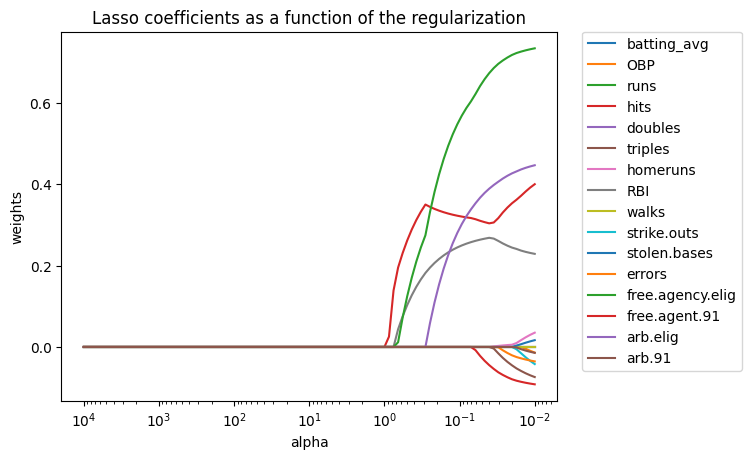

In [302]:
alphas = np.logspace(-2, 4, 100)
coefs = []
for a in alphas:
    LR = Lasso(alpha=a, fit_intercept=True)
    LR.fit(x_train_scaled, y_train)
    coefs.append(LR.coef_)


ax = plt.gca()

ax.plot(alphas, coefs,label=x.columns)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Lasso coefficients as a function of the regularization")
plt.axis("tight")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.show()

From this graph, I can see that as the alpha gets smaller, more of my features will be used in my final model. As expected with Lasso regularization, I see that this method restricts all feature weights to zero at a lower alpha than the Elastic Net method, making the viable threshold of Lasso regularization smaller.

In [303]:
model4 = Lasso(alpha=al,  max_iter=1000, copy_X=True, tol=0.001)
model4.fit(x_train_scaled, y_train)

Lasso(alpha=0.011497569953977356, tol=0.001)

In [304]:
print("TRAINING DATA RESULTS")

r_sq5 = model4.score(x_train_scaled, y_train)
print("\ncoefficient of determination:",r_sq5)
print("intercept:", model4.intercept_)
print("feature coefficients:", model4.coef_)

print("\nTESTING DATA RESULTS")
predict5=model4.predict(x_test_scaled)

print("R score:", r2_score(y_test,predict5))
print("mean squared error:", mean_squared_error(y_test,predict5))
print("MSE:", mean_squared_error(y_test,predict5))
print("mean absolute error:", mean_absolute_error(y_test,predict5))

TRAINING DATA RESULTS

coefficient of determination: 0.8452940236069704
intercept: 6.4629058832101425
feature coefficients: [ 0.         -0.00971545 -0.          0.39571932 -0.         -0.06932386
  0.03544808  0.22428313  0.         -0.03586265  0.01362003 -0.03333616
  0.73075005 -0.08941537  0.44333824 -0.01203951]

TESTING DATA RESULTS
R score: 0.6039955921644066
mean squared error: 0.5037375318022788
MSE: 0.5037375318022788
mean absolute error: 0.5329040186382416


From my Lasso regularization, I can see that the 4 coefficients that had their weights reduced to zero (batting_avg, runs, doubles, walks) are the same as those in my Elastic Net model. While none of the metrics (except mean absolute error) outperformed my Ridge model, they all outperformed the rest of my models. At this point it should be noted that while each of my regularization models might have benifitted from different arguments, I kept them all the same to ensure an easily comparison between the performance of the methods.

For ease of comparision, all off the evaluation metrics are listed below in the following order: Basic Regression, Selection, Elastic Net, Ridge, Lasso.

In [305]:
print("TRAINING DATA RESULTS")

print("\ncoefficient of determination:",r_sq, ",",r_sq2, ",", r_sq3, ",",r_sq4,",",r_sq5)

print("\nTESTING DATA RESULTS")

print("R score:", r2_score(y_test,predict),",",r2_score(y_test2,predict2),",",r2_score(y_test,predict3),",",r2_score(y_test,predict4),",",r2_score(y_test,predict5))
print("mean squared error:", mean_squared_error(y_test,predict),",",mean_squared_error(y_test2,predict2),",",mean_squared_error(y_test,predict3),",",mean_squared_error(y_test,predict4),",",mean_squared_error(y_test,predict5))
print("MSE:", mean_squared_error(y_test,predict),mean_squared_error(y_test2,predict2),",",mean_squared_error(y_test,predict3),",",mean_squared_error(y_test,predict4),",",mean_squared_error(y_test,predict5))
print("mean absolute error:", mean_absolute_error(y_test,predict),",",mean_absolute_error(y_test2,predict2),",",mean_absolute_error(y_test,predict3),",",mean_absolute_error(y_test,predict4),",",mean_absolute_error(y_test,predict5))

TRAINING DATA RESULTS

coefficient of determination: 0.850301816981162 , 0.8448245666378563 , 0.8451084881742641 , 0.8488252201097183 , 0.8452940236069704

TESTING DATA RESULTS
R score: 0.5960451066468704 , 0.5988238913160369 , 0.602849422524315 , 0.6045641417412583 , 0.6039955921644066
mean squared error: 0.5138509494107417 , 0.5103161954964948 , 0.5051955172542139 , 0.5030143081338457 , 0.5037375318022788
MSE: 0.5138509494107417 0.5103161954964948 , 0.5051955172542139 , 0.5030143081338457 , 0.5037375318022788
mean absolute error: 0.535438960766149 , 0.5328733344837502 , 0.5351103527269642 , 0.5337347954778872 , 0.5329040186382416


### Comparitive Graphs

In [306]:
lambdas = np.logspace(-2, 4, 100)

def get_mse_and_coefs(model_class, X_train, y_train, X_test, y_test, lambdas):
    mses = []
    coefs = []

    for alpha in lambdas:
        model = model_class(alpha=alpha)
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
        mse = mean_squared_error(y_test, y_pred)

        mses.append(mse)
        coefs.append(model.coef_)

    return mses, np.array(coefs)

ridge_mses, ridge_coefs = get_mse_and_coefs(Ridge, x_train, y_train, x_test, y_test, lambdas)
lasso_mses, lasso_coefs = get_mse_and_coefs(Lasso, x_train, y_train, x_test, y_test, lambdas)
elasticnet_mses, elasticnet_coefs = get_mse_and_coefs(ElasticNet, x_train, y_train, x_test, y_test, lambdas)


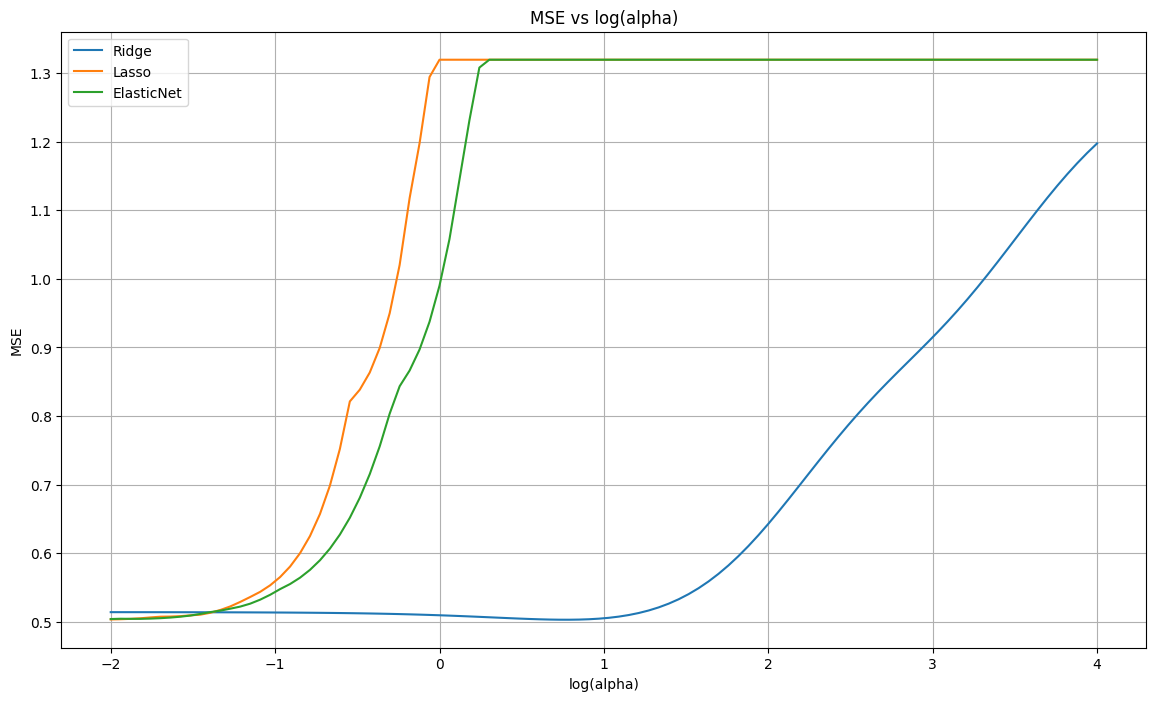

In [307]:
plt.figure(figsize=(14, 8))
plt.plot(np.log10(lambdas), ridge_mses, label='Ridge')
plt.plot(np.log10(lambdas), lasso_mses, label='Lasso')
plt.plot(np.log10(lambdas), elasticnet_mses, label='ElasticNet')
plt.xlabel('log(alpha)')
plt.ylabel('MSE')
plt.title('MSE vs log(alpha)')
plt.legend()
plt.grid(True)
plt.show()

This graph outlines the relationship between alpha and MSE for each regularization method. This graph comfirms my findings that Ridge regularization will always result in the smallest MSE, except when alpha is extremely small. Interestingly, Lasso and ElasticNet are almost translations of each other, with Elastic net providing lower MSE values for all alphass. I can also gather than overall, Ridge regularization has the smallest range of results, whereas the other two methods have the same range. Originally, there was some confusion as to why Ridge regularization preferred an alpha that was so much higher than those of Elastic Net and Lasso, but after looking at this graph, it makes sense as that value is where the MSE is the lowest.

## 5. Comparison of Regularization Methods

From the results of the three penalizations (Lasso, Ridge, Elastic Net), it is evident that Lasso regularization penalizes the predictors the most. This conclusion comes from the fact that while both Lasso and Elastic Net pushed the same feature coefficients to zero, Lasso regularization pushed all the feature coefficients to zero at a lower alpha.

When alpha is equal to 0, each of the regularization methods yield the same results as the oridinary least square regression.

## 6. Interactions

Now that I have exhausted my options using the dataset as is, I will attempt to create new variables using my existing ones with the goal of creating a better model than before. The first thing I must do is check the correlation of my variables so that I do not introduce multi-collinearity. I will then multiply the least correlated variables to create 4 new features.

In [308]:
corr = x.corr()
corr.style.background_gradient(cmap='coolwarm') \
    .format(precision=3) \
    .set_properties(**{'font-size': '7pt'})

,batting_avg,OBP,runs,hits,doubles,triples,homeruns,RBI,walks,strike.outs,stolen.bases,errors,free.agency.elig,free.agent.91,arb.elig,arb.91
batting_avg,1.000,0.806,0.437,0.508,0.452,0.264,0.213,0.370,0.280,0.076,0.201,0.145,0.057,-0.034,0.096,0.089
OBP,0.806,1.000,0.514,0.457,0.404,0.199,0.311,0.399,0.590,0.208,0.230,0.095,0.172,-0.037,0.014,0.047
runs,0.437,0.514,1.000,0.923,0.832,0.549,0.681,0.833,0.828,0.685,0.526,0.342,0.300,-0.006,0.146,0.132
hits,0.508,0.457,0.923,1.000,0.889,0.544,0.614,0.852,0.723,0.646,0.429,0.416,0.293,0.035,0.188,0.148
doubles,0.452,0.404,0.832,0.889,1.000,0.417,0.635,0.825,0.640,0.601,0.293,0.339,0.225,-0.008,0.201,0.158
triples,0.264,0.199,0.549,0.544,0.417,1.000,0.125,0.331,0.308,0.329,0.529,0.198,0.059,-0.004,0.160,0.101
homeruns,0.213,0.311,0.681,0.614,0.635,0.125,1.000,0.877,0.625,0.749,0.078,0.152,0.298,-0.025,0.039,0.038
RBI,0.370,0.399,0.833,0.852,0.825,0.331,0.877,1.000,0.727,0.745,0.206,0.293,0.308,0.024,0.127,0.096
walks,0.280,0.590,0.828,0.723,0.640,0.308,0.625,0.727,1.000,0.666,0.355,0.243,0.351,0.017,0.031,0.040
strike.outs,0.076,0.208,0.685,0.646,0.601,0.329,0.749,0.745,0.666,1.000,0.279,0.302,0.225,-0.010,0.039,0.049


In [309]:
datat_int = datat.copy()
datat_int['OBP_doubles'] = datat['OBP']*datat['doubles']
datat_int['RBI_triples'] = datat['RBI']*datat['triples']
datat_int['errors_homeruns'] = datat['errors']*datat['homeruns']
datat_int['hits_batting_avg'] = datat['hits']*datat['batting_avg']

In [310]:
yi = datat_int['salary']
xi = datat_int.drop(['salary', 'name'], axis=1)

xi_train, xi_test, yi_train, yi_test = train_test_split(xi, yi, test_size=0.33, random_state=123)

scaler = StandardScaler()
xi_train_scaled = scaler.fit_transform(xi_train)
xi_test_scaled = scaler.transform(xi_test)

In [311]:
modeli = LinearRegression()
modeli.fit(xi_train_scaled, yi_train)

LinearRegression()

In [312]:
print("TRAINING DATA RESULTS")

r_sq6 = modeli.score(xi_train_scaled, yi_train)
print("\ncoefficient of determination:",r_sq6)
print("intercept:", modeli.intercept_)
print("feature coefficients:", modeli.coef_)

print("\nTESTING DATA RESULTS")
predict6=modeli.predict(xi_test_scaled)

print("R score:", r2_score(yi_test,predict6))
print("mean squared error:", mean_squared_error(yi_test,predict6))
print("MSE:", mean_squared_error(yi_test,predict6))
print("mean absolute error:", mean_absolute_error(yi_test,predict6))

TRAINING DATA RESULTS

coefficient of determination: 0.854126317289061
intercept: 6.4629058832101425
feature coefficients: [ 0.10091041 -0.10584406 -0.09608583  1.78607643 -0.87093966 -0.17303445
  0.15617033  0.15281787 -0.04474487 -0.15437867  0.05166007 -0.0161625
  0.74962331 -0.10624131  0.46777508 -0.02407784  0.88143174  0.1177409
 -0.07365645 -1.24624235]

TESTING DATA RESULTS
R score: 0.6461005923234885
mean squared error: 0.4501778530790156
MSE: 0.4501778530790156
mean absolute error: 0.5055137197179322


Out of all my previous models, this model yields the highest testing R score and lowest MSE, making it my best model thus far. This model's performance may have been further imporved by using a different combination of my 8 variables and completely removing them in favour of my 4 new features since the method that I use probably introduced some multi-collinearity to my model. It is likely that using regularization on this model would yield even better results.

For my last model, I will take my two continuous variables (OBP and batting_avg) and attempt to linearize them using transformation functions. First, I will graph the two variables to see their relationship, then I will apply the functions and graph them again to see their change.

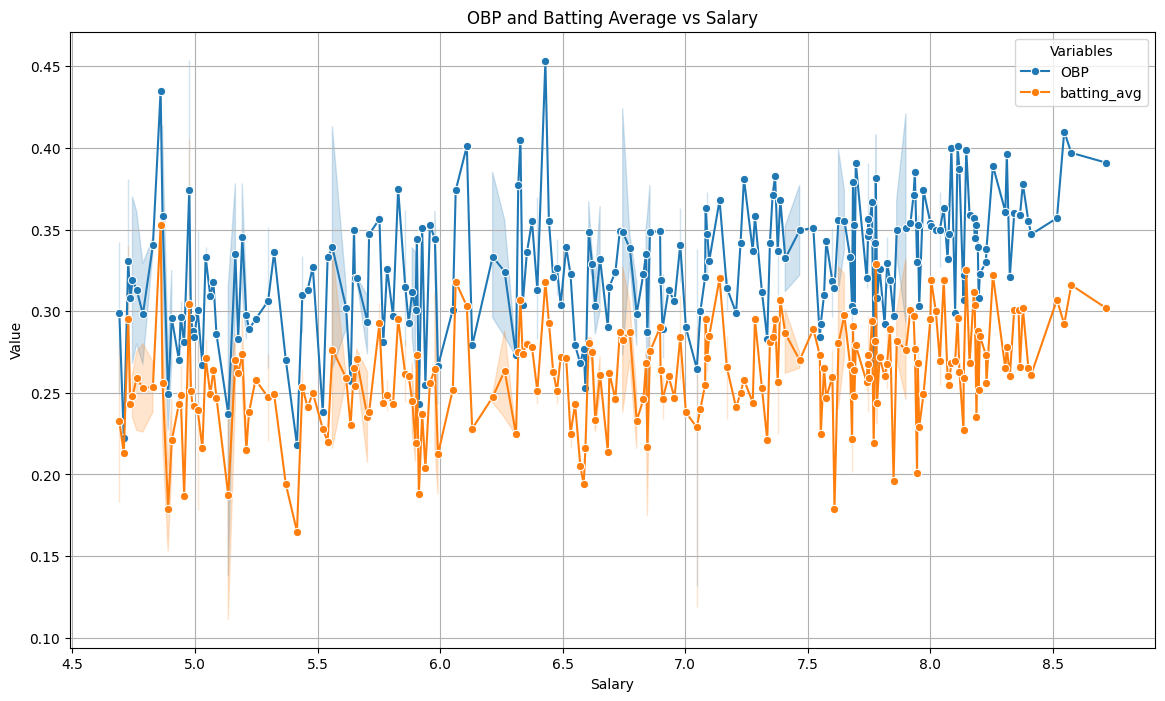

In [313]:
datat_selected = datat[['salary', 'OBP', 'batting_avg']]

datat_melted = datat_selected.melt(id_vars='salary', var_name='variable', value_name='value')

plt.figure(figsize=(14, 8))
sns.lineplot(data=datat_melted, x='salary', y='value', hue='variable', marker='o')

plt.title('OBP and Batting Average vs Salary')
plt.xlabel('Salary')
plt.ylabel('Value')
plt.legend(title='Variables')
plt.grid(True)
plt.show()

In [314]:
datattr = datat.drop(['OBP','batting_avg'], axis=1)
datattr['OBP_sqr'] = datat['OBP']**(1/2)
datattr['batting_avg_squared'] = datat['batting_avg']**2

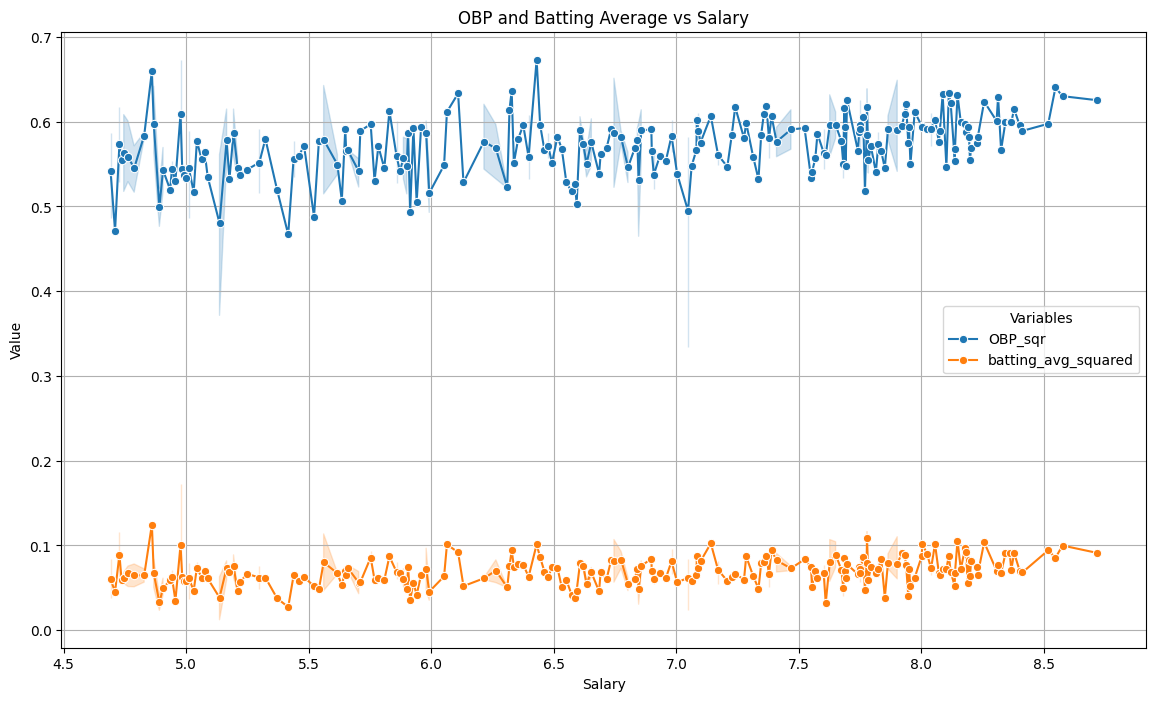

In [315]:
datat_selected2 = datattr[['salary', 'OBP_sqr', 'batting_avg_squared']]

datat_melted = datat_selected2.melt(id_vars='salary', var_name='variable', value_name='value')

plt.figure(figsize=(14, 8))
sns.lineplot(data=datat_melted, x='salary', y='value', hue='variable', marker='o')

plt.title('OBP and Batting Average vs Salary')
plt.xlabel('Salary')
plt.ylabel('Value')
plt.legend(title='Variables')
plt.grid(True)
plt.show()

While I did not completely linearize them, I can see that I were able to flatten each of these variables, which should help my predictions.

In [316]:
yt = datattr['salary']
xt = datattr.drop(['salary','name'], axis=1)

xt_train, xt_test, yt_train, yt_test = train_test_split(xt, yt, test_size=0.33, random_state=123)

scaler = StandardScaler()
xt_train_scaled = scaler.fit_transform(xt_train)
xt_test_scaled = scaler.transform(xt_test)

In [317]:
modelt = LinearRegression()
modelt.fit(xt_train_scaled, yt_train)

LinearRegression()

In [318]:
print("TRAINING DATA RESULTS")

r_sq7 = modelt.score(xt_train_scaled, yt_train)
print("\ncoefficient of determination:",r_sq7)
print("intercept:", modelt.intercept_)
print("feature coefficients:", modelt.coef_)

print("\nTESTING DATA RESULTS")
predict7=modelt.predict(xt_test_scaled)

print("R score:", r2_score(yt_test,predict7))
print("mean squared error:", mean_squared_error(yt_test,predict7))
print("MSE:", mean_squared_error(yt_test,predict7))
print("mean absolute error:", mean_absolute_error(yt_test,predict7))

TRAINING DATA RESULTS

coefficient of determination: 0.8499270043652807
intercept: 6.4629058832101425
feature coefficients: [-0.16220913  0.61309381 -0.08348214 -0.09025023  0.11872384  0.1940851
  0.05545619 -0.09963052  0.05590377 -0.05569148  0.7469576  -0.10571135
  0.46984474 -0.02155688 -0.05603599  0.01419306]

TESTING DATA RESULTS
R score: 0.6525062322452307
mean squared error: 0.4420295567975958
MSE: 0.4420295567975958
mean absolute error: 0.4989199651318908


Like with my feature interactions, these transformation created a much better model than my previous models. It is likely that experimenting with more transformation functions may yield better results, as the graph suggests that there is more room for linearizing. Based on my finding throughout this project, using interactions, transformations and regularization in tandem will yield the best possible linear regression model.

# Attempt at combining all previous methods

While outside the scope of this project, I thought it would be interesting to see if the conclusion was correct. This "ultra" model is cfreated by taking the data frame that was used for the transformations, applying the same interactions, removing the features used in those interactions and then applying Ridge regression. This model beat the performance of all my other models, which is in line with my conclusions from the project. To further improve this model, I would try using different interactions and transformation functions.

In [319]:
datau = datattr.copy()

datau['OBP_doubles'] = datattr['OBP_sqr']*datat['doubles']
datau['RBI_triples'] = datat['RBI']*datat['triples']
datau['errors_homeruns'] = datat['errors']*datat['homeruns']
datau['hits_batting_avg'] = datat['hits']*datattr['batting_avg_squared']

yu = datau['salary']
xu = datau.drop(['salary','name','OBP_sqr','doubles','RBI','triples','errors','homeruns','hits','batting_avg_squared'], axis=1)

xu_train, xu_test, yu_train, yu_test = train_test_split(xu, yu, test_size=0.33, random_state=123)

scaler = StandardScaler()
xu_train_scaled = scaler.fit_transform(xu_train)
xu_test_scaled = scaler.transform(xu_test)

#Ridge Regression

modelurr = RidgeCV(alphas=np.logspace(-2, 4, 100), fit_intercept=True, cv=None)
modelurr.fit(xu_train_scaled, yu_train)

alu=modelurr.alpha_
print("Ideal alpha:",alu)

modelu = Ridge(alpha=al,  max_iter=1000, copy_X=True, tol=0.001)
modelu.fit(xu_train_scaled, yu_train)

print("\nTRAINING DATA RESULTS")

r_squ = modelu.score(xu_train_scaled, yu_train)
print("\ncoefficient of determination:",r_squ)
print("intercept:", modelu.intercept_)
print("feature coefficients:", modelu.coef_)

print("\nTESTING DATA RESULTS")
predictu=modelu.predict(xu_test_scaled)

print("R score:", r2_score(yu_test,predictu))
print("mean squared error:", mean_squared_error(yu_test,predictu))
print("MSE:", mean_squared_error(yu_test,predictu))
print("mean absolute error:", mean_absolute_error(yu_test,predictu))

Ideal alpha: 9.326033468832199

TRAINING DATA RESULTS

coefficient of determination: 0.8175572169884755
intercept: 6.4629058832101425
feature coefficients: [ 0.12329995  0.03967359  0.09351074 -0.04036996  0.80562337 -0.11514993
  0.49374171 -0.04673365  0.06042179 -0.05321736  0.00292913  0.29796197]

TESTING DATA RESULTS
R score: 0.6529151848890289
mean squared error: 0.4415093484581562
MSE: 0.4415093484581562
mean absolute error: 0.49442550339483177
